# V2 백테스트 v9 — 2-Factor Market Model
### 시장 노이즈 + 보험업 노이즈 동시 제거

---

**핵심 차이 (vs v8)**:
- v8: 시장 노이즈만 제거 (1-factor): $R_{firm} = \alpha + \beta R_{market} + \epsilon$
- v9: 시장 + 보험업 동시 제거 (**2-factor**): $R_{firm} = \alpha + \beta_1 R_{market} + \beta_2 R_{insurance} + \epsilon$

→ 최종 AR = 회사 고유 ESG 효과만 남음 (시장 거시 영향 + 보험업 산업 영향 모두 제거됨)

---

**회사별 보험업 proxy**:

| 회사 | 본국 | 시장 인덱스 | 보험업 proxy |
|---|---|---|---|
| Swiss Re | 스위스/유럽 | STOXX 600 | iShares STOXX 600 Insurance ETF (`EXH5.DE`) |
| Munich Re | 독일/유럽 | STOXX 600 | iShares STOXX 600 Insurance ETF (`EXH5.DE`) |
| SCOR | 프랑스/유럽 | STOXX 600 | iShares STOXX 600 Insurance ETF (`EXH5.DE`) |
| Tokio Marine | 일본 | Nikkei 225 | NEXT FUNDS TOPIX-17 보험 ETF (`1617.T`) |
| QBE | 호주 | ASX 200 | 호주 보험사 평균 (IAG, SUN, MPL) |

---

[런타임] → [모두 실행]. 첫 실행 시 yfinance로 보험업 ETF 데이터 추가 다운로드함.

## 0. 환경 설정

In [ ]:
!pip install -q koreanize-matplotlib yfinance statsmodels
!apt-get install -y fonts-nanum > /dev/null 2>&1

import koreanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm

mpl.rcParams['axes.unicode_minus'] = False

# ONE CAPITAL 컬러
C = {
    'main':'#0F1419','secondary':'#94A3B8','tertiary':'#CBD5E1',
    'pos':'#16A34A','neg':'#DC2626','accent':'#E11D48',
    'highlight':'#F59E0B','muted':'#64748B',
}

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.edgecolor':'#0F172A','axes.linewidth':0.7,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.titleweight':'bold','axes.titlesize':11.5,
    'axes.titlepad':12,'axes.titlelocation':'left',
    'axes.labelsize':9.5,'axes.labelcolor':'#475569',
    'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.5,'grid.color':'#F1F5F9','grid.linewidth':0.5,
    'xtick.color':'#64748B','ytick.color':'#64748B',
    'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.frameon':False,'legend.fontsize':9,
    'lines.linewidth':1.6,'font.size':9.5,'figure.dpi':110,
})
print('Setup OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 24.6 MB/s eta 0:00:00
Setup OK


## 1. 기존 주가 데이터 로드

In [ ]:
from google.colab import files
import io

print("v2_backtest_data.csv 업로드...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), parse_dates=['Date'])
df = df.set_index('Date').sort_index()
print(f"Loaded: {len(df):,} days × {len(df.columns)} tickers")
print(f"Period: {df.index[0].date()} ~ {df.index[-1].date()}")

v2_backtest_data.csv 업로드...


Saving v2_backtest_data.csv to v2_backtest_data.csv
Loaded: 2,082 days × 18 tickers
Period: 2017-01-02 ~ 2024-12-30


## 2. 보험업 ETF/지수 추가 다운로드 (yfinance)

In [ ]:
print("Downloading insurance sector indices/ETFs...")

# 시도할 ticker들
ins_tickers = {
    'EU_INS':  'EXH5.DE',  # iShares STOXX 600 Insurance ETF
    'JP_INS':  '1617.T',   # NEXT FUNDS TOPIX-17 보험 ETF
    'AU_IAG':  'IAG.AX',   # Insurance Australia Group
    'AU_SUN':  'SUN.AX',   # Suncorp
    'AU_MPL':  'MPL.AX',   # Medibank
}

ins_raw = {}
start_date = df.index[0].strftime('%Y-%m-%d')
end_date = (df.index[-1] + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

for name, tk in ins_tickers.items():
    try:
        d = yf.download(tk, start=start_date, end=end_date,
                        progress=False, auto_adjust=True)
        close = d['Close'].squeeze()
        if len(close) > 500:
            ins_raw[name] = close
            print(f"  ✓ {name} ({tk}): {len(close):,} days")
        else:
            print(f"  ✗ {name} ({tk}): only {len(close)} days")
    except Exception as e:
        print(f"  ✗ {name} ({tk}): error - {str(e)[:50]}")

# 보험업 proxy 구축 (df와 같은 index로 align)
insurance_indices = pd.DataFrame(index=df.index)

# 유럽
if 'EU_INS' in ins_raw:
    insurance_indices['EU_INS'] = ins_raw['EU_INS'].reindex(df.index).ffill()
    print(f"\n  EU insurance proxy: EXH5.DE")

# 일본
if 'JP_INS' in ins_raw:
    insurance_indices['JP_INS'] = ins_raw['JP_INS'].reindex(df.index).ffill()
    print(f"  JP insurance proxy: 1617.T (TOPIX-17 보험)")

# 호주: IAG, SUN, MPL의 동등가중 평균
au_tks = [k for k in ['AU_IAG', 'AU_SUN', 'AU_MPL'] if k in ins_raw]
if len(au_tks) >= 2:
    au_df = pd.concat([ins_raw[k] for k in au_tks], axis=1)
    au_df.columns = au_tks
    au_aligned = au_df.reindex(df.index).ffill().bfill()  # bfill 추가: 첫날 NaN 해결
    # Normalize 각 firm 후 평균 → 동등가중 portfolio index
    au_norm = au_aligned.divide(au_aligned.iloc[0]) * 100
    insurance_indices['AU_INS'] = au_norm.mean(axis=1)
    print(f"  AU insurance proxy: equal-weighted avg of {au_tks}")

# 통합 returns 데이터프레임
returns = df.pct_change()
ins_returns = insurance_indices.pct_change()

print(f"\nInsurance proxies ready: {list(insurance_indices.columns)}")

# 진단
for col in insurance_indices.columns:
    s = insurance_indices[col].dropna()
    if len(s)>0:
        print(f'  {col}: {len(s):,} days, first={s.iloc[0]:.2f}, last={s.iloc[-1]:.2f}')

  ✓ EU_INS (EXH5.DE): 2,007 days
  ✓ JP_INS (1617.T): 1,976 days
  ✓ AU_IAG (IAG.AX): 2,023 days
  ✓ AU_SUN (SUN.AX): 2,023 days
  ✓ AU_MPL (MPL.AX): 2,023 days

  EU insurance proxy: EXH5.DE
  JP insurance proxy: 1617.T (TOPIX-17 보험)
  AU insurance proxy: equal-weighted avg of ['AU_IAG', 'AU_SUN', 'AU_MPL']

Insurance proxies ready: ['EU_INS', 'JP_INS', 'AU_INS']
  EU_INS: 2,082 days, first=26.19, last=40.66
  JP_INS: 2,080 days, first=25153.46, last=36978.97
  AU_INS: 2,082 days, first=100.00, last=195.44


/tmp/ipykernel_3048/3135338671.py:54: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change()


## 3. 회사 - 시장 - 보험업 proxy 매핑

In [ ]:
# 5개 양 이벤트 + 시장 + 보험업 매핑
EVENTS = [
    ('2018-07-02', 'SREN.SW',  '^STOXX', 'EU_INS',  'Swiss Re',     'Thermal Coal 정책'),
    ('2021-04-08', 'MUV2.DE',  '^STOXX', 'EU_INS',  'Munich Re',    'NZIA 창립'),
    ('2021-04-30', 'SCR.PA',   '^STOXX', 'EU_INS',  'SCOR',         'Net-Zero 가속'),
    ('2022-01-20', '8766.T',   '^N225',  'JP_INS',  'Tokio Marine', 'NZIA 가입'),
    ('2022-02-11', 'QBE.AX',   '^AXJO',  'AU_INS',  'QBE',          'Sustainable Energies'),
]

market_names = {'^STOXX':'STOXX 600','^N225':'Nikkei 225','^AXJO':'ASX 200'}
ins_names = {
    'EU_INS':'STOXX 600 Insurance ETF',
    'JP_INS':'TOPIX-17 Insurance ETF',
    'AU_INS':'AU Insurance Portfolio',
}

# 표 출력
import pandas as pd
mapping_df = pd.DataFrame([
    {'그룹':'Treatment', '회사':e[4], 'Ticker':e[1],
     '본국':{'^STOXX':'유럽','^N225':'일본','^AXJO':'호주'}[e[2]],
     '시장':market_names[e[2]], '보험업 Proxy':ins_names[e[3]],
     '이벤트':f"{e[5]} ({e[0]})"} for e in EVENTS
])
mapping_df.style.set_properties(**{
    'text-align':'left','padding':'8px 14px','font-size':'12px'
}).set_table_styles([
    {'selector':'th','props':[('background-color','#0F1419'),('color','white'),
     ('font-weight','bold'),('padding','10px 14px'),('text-align','left')]},
])

,그룹,회사,Ticker,본국,시장,보험업 Proxy,이벤트
0,Treatment,Swiss Re,SREN.SW,유럽,STOXX 600,STOXX 600 Insurance ETF,Thermal Coal 정책 (2018-07-02)
1,Treatment,Munich Re,MUV2.DE,유럽,STOXX 600,STOXX 600 Insurance ETF,NZIA 창립 (2021-04-08)
2,Treatment,SCOR,SCR.PA,유럽,STOXX 600,STOXX 600 Insurance ETF,Net-Zero 가속 (2021-04-30)
3,Treatment,Tokio Marine,8766.T,일본,Nikkei 225,TOPIX-17 Insurance ETF,NZIA 가입 (2022-01-20)
4,Treatment,QBE,QBE.AX,호주,ASX 200,AU Insurance Portfolio,Sustainable Energies (2022-02-11)


## 4. Helper: 2-Factor Market Model 함수

In [ ]:
def get_ar_2factor(ticker, event_date, market, insurance, evt_start=-90, evt_end=90):
    """2-factor Market Model:
       R_firm = α + β1·R_market + β2·R_insurance + ε
       AR = R_firm − (α + β1·R_market + β2·R_insurance)
       → 시장 노이즈 + 보험업 노이즈 동시 제거된 순수 firm-specific abnormal return
    """
    series = returns[ticker].dropna()
    edt = pd.Timestamp(event_date)
    after = series.index[series.index >= edt]
    t0_pos = series.index.get_loc(after[0])

    # Estimation window
    est_idx = series.index[t0_pos+evt_start-220:t0_pos+evt_start-30]

    # 회귀 데이터프레임 (시장 + 보험업)
    reg = pd.DataFrame({
        'y':   returns.loc[est_idx, ticker],
        'mkt': returns.loc[est_idx, market],
        'ins': ins_returns.loc[est_idx, insurance],
    }).dropna()

    if len(reg) < 50:
        return None

    # 2-factor OLS regression
    X = sm.add_constant(reg[['mkt','ins']])
    model = sm.OLS(reg['y'], X).fit()
    alpha = model.params['const']
    beta_mkt = model.params['mkt']
    beta_ins = model.params['ins']
    r2 = model.rsquared

    # 비교: 1-factor (시장만)
    X1 = sm.add_constant(reg[['mkt']])
    model1 = sm.OLS(reg['y'], X1).fit()
    r2_1f = model1.rsquared

    # Event window
    evt_idx = series.index[t0_pos+evt_start:t0_pos+evt_end+1]
    evt_data = pd.DataFrame({
        'y':   returns.loc[evt_idx, ticker],
        'mkt': returns.loc[evt_idx, market],
        'ins': ins_returns.loc[evt_idx, insurance],
    })

    # 2-factor 예측 + AR
    pred = alpha + beta_mkt*evt_data['mkt'] + beta_ins*evt_data['ins']
    ar = evt_data['y'] - pred

    return {
        'days': np.arange(len(evt_idx))+evt_start,
        'actual': evt_data['y']*100,
        'predicted': pred*100,
        'ar': ar*100,
        'cum_ar': ar.cumsum()*100,
        'alpha': alpha, 'beta_mkt': beta_mkt, 'beta_ins': beta_ins,
        'r2': r2, 'r2_1f': r2_1f, 'r2_delta': r2 - r2_1f,
        'reg_data': reg, 'n_est': len(reg),
    }

print('get_ar_2factor() ready')

get_ar_2factor() ready


## 5. Helper: 회사별 4-Panel 시각화

In [ ]:
def plot_company_panel(ticker, event_date, market, insurance, firm_name, event_name):
    """한 회사의 2-factor CAR 산출 4-panel 시각화"""
    edt = pd.Timestamp(event_date)
    res = get_ar_2factor(ticker, event_date, market, insurance, -90, 90)
    market_name = market_names[market]
    ins_name = ins_names[insurance]

    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.25)

    # ━━━━ Panel 1: 회사 vs 시장 vs 보험업 ━━━━
    ax1 = fig.add_subplot(gs[0, 0])
    s = df[ticker].dropna()
    norm = s / s.iloc[0] * 100
    s_m = df[market].dropna()
    norm_m = s_m / s_m.iloc[0] * 100
    s_i = insurance_indices[insurance].dropna()
    norm_i = s_i / s_i.iloc[0] * 100

    # 시장 (연한 회색 점선)
    ax1.plot(norm_m.index, norm_m.values, color=C['tertiary'],
             linewidth=1.0, alpha=0.7, linestyle='--', zorder=3)
    # 보험업 (중간 회색)
    ax1.plot(norm_i.index, norm_i.values, color=C['secondary'],
             linewidth=1.3, alpha=0.85, zorder=4)
    # 회사 (검정)
    ax1.plot(norm.index, norm.values, color=C['main'],
             linewidth=2.0, zorder=5)

    # 이벤트일
    ax1.axvline(edt, color=C['pos'], linewidth=1.2, alpha=0.7, zorder=4)
    try: v_evt = norm.loc[edt:].iloc[0]
    except: v_evt = norm.iloc[-1]
    ax1.scatter([edt], [v_evt], s=80, color='white',
                edgecolor=C['pos'], linewidth=2, zorder=10)

    y_range = norm.max() - norm.min()
    ax1.annotate(f'{event_name}\n{event_date}',
                xy=(edt, v_evt), xytext=(15, y_range*0.15),
                textcoords='offset points',
                fontsize=9, color=C['pos'], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                          edgecolor=C['pos'], linewidth=1.2),
                arrowprops=dict(arrowstyle='->', color=C['pos'], lw=1.2))

    # 우측 라벨
    ax1.annotate(firm_name, xy=(norm.index[-1], norm.iloc[-1]),
                xytext=(6, 0), textcoords='offset points', va='center',
                fontsize=10, fontweight='bold', color=C['main'])
    ax1.annotate(f'{insurance}', xy=(norm_i.index[-1], norm_i.iloc[-1]),
                xytext=(6, 0), textcoords='offset points', va='center',
                fontsize=9, color=C['secondary'])
    ax1.annotate(market_name, xy=(norm_m.index[-1], norm_m.iloc[-1]),
                xytext=(6, 0), textcoords='offset points', va='center',
                fontsize=8.5, color=C['tertiary'])

    ax1.axhline(100, color='#0F172A', linewidth=0.3, alpha=0.4)
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.set_title('① Stock Price + Market + Insurance Sector + Event')
    ax1.set_ylabel('Price (start=100)')

    # ━━━━ Panel 2: Partial Regression (보험업 영향, 시장 제거 후) ━━━━
    ax2 = fig.add_subplot(gs[0, 1])

    # 시장 영향 제거 후 잔차 (FWL theorem)
    reg = res['reg_data']
    X_m_only = sm.add_constant(reg['mkt'])
    y_resid_mkt = reg['y'] - sm.OLS(reg['y'], X_m_only).fit().fittedvalues
    ins_resid_mkt = reg['ins'] - sm.OLS(reg['ins'], X_m_only).fit().fittedvalues

    # Partial scatter
    ax2.scatter(ins_resid_mkt*100, y_resid_mkt*100, s=14, color=C['main'],
                alpha=0.4, edgecolor='none', zorder=3)

    # Partial regression line (slope = β_ins)
    x_line = np.linspace(ins_resid_mkt.min()*100, ins_resid_mkt.max()*100, 50)
    y_line = res['beta_ins'] * x_line
    ax2.plot(x_line, y_line, color=C['accent'], linewidth=2.2, zorder=5)

    ax2.axhline(0, color='#0F172A', linewidth=0.3, alpha=0.4)
    ax2.axvline(0, color='#0F172A', linewidth=0.3, alpha=0.4)

    # 통계 box
    box_text = (f'2-Factor OLS Coefficients\n'
                f'─────────────────\n'
                f'α           = {res["alpha"]*100:+.4f}%/d\n'
                f'β_market   = {res["beta_mkt"]:+.3f}\n'
                f'β_insurance = {res["beta_ins"]:+.3f}\n'
                f'R² (2-fac)  = {res["r2"]:.3f}\n'
                f'R² (1-fac)  = {res["r2_1f"]:.3f}\n'
                f'ΔR² (보험업) = +{res["r2_delta"]:.3f}')
    ax2.text(0.04, 0.96, box_text, transform=ax2.transAxes,
             ha='left', va='top', fontsize=8.5, fontweight='bold',
             family='monospace', color=C['main'],
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                       edgecolor=C['main'], linewidth=1))

    ax2.set_title('② Partial Regression — 보험업 영향 (시장 제거 후)')
    ax2.set_xlabel(f'{insurance} return residual (after market) (%)')
    ax2.set_ylabel(f'{firm_name} return residual (after market) (%)')

    # ━━━━ Panel 3: Actual vs 2-factor Predicted ━━━━
    ax3 = fig.add_subplot(gs[1, 0])
    actual_cum = (1 + res['actual']/100).cumprod() * 100 - 100
    pred_cum = (1 + res['predicted']/100).cumprod() * 100 - 100

    ax3.fill_between(res['days'], actual_cum, pred_cum,
                     where=(actual_cum >= pred_cum), alpha=0.15, color=C['pos'])
    ax3.fill_between(res['days'], actual_cum, pred_cum,
                     where=(actual_cum < pred_cum), alpha=0.15, color=C['neg'])

    ax3.plot(res['days'], pred_cum, color=C['secondary'], linewidth=1.4,
             linestyle='--', zorder=4)
    ax3.plot(res['days'], actual_cum, color=C['main'], linewidth=2.1, zorder=5)

    ax3.annotate(f'Actual: {actual_cum.iloc[-1]:+.1f}%',
                 xy=(res['days'][-1], actual_cum.iloc[-1]),
                 xytext=(6, 0), textcoords='offset points', va='center',
                 fontsize=10, fontweight='bold', color=C['main'])
    ax3.annotate(f'Predicted (2-fac): {pred_cum.iloc[-1]:+.1f}%',
                 xy=(res['days'][-1], pred_cum.iloc[-1]),
                 xytext=(6, 0), textcoords='offset points', va='center',
                 fontsize=9.5, color=C['secondary'])

    ax3.axvline(0, color=C['highlight'], linewidth=1.3, alpha=0.7)
    ax3.axhline(0, color='#0F172A', linewidth=0.4)
    ax3.set_title('③ Actual vs 2-factor Predicted Cumulative Return (±90d)')
    ax3.set_xlabel('Trading days from event')
    ax3.set_ylabel('Cumulative Return (%)')

    # ━━━━ Panel 4: 최종 CAR (2-factor) ━━━━
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.fill_between(res['days'], res['cum_ar'], 0,
                     where=(res['cum_ar'] > 0), alpha=0.22, color=C['pos'])
    ax4.fill_between(res['days'], res['cum_ar'], 0,
                     where=(res['cum_ar'] <= 0), alpha=0.22, color=C['neg'])
    ax4.plot(res['days'], res['cum_ar'], color=C['main'], linewidth=2.1, zorder=5)

    for d_idx, d_label in [(95, '+5d'), (120, '+30d'), (150, '+60d'), (180, '+90d')]:
        if d_idx < len(res['cum_ar']):
            v = res['cum_ar'].iloc[d_idx]
            ax4.scatter([res['days'][d_idx]], [v], s=55, color='white',
                        edgecolor=C['main'], linewidth=1.8, zorder=10)
            offset = 10 if v >= 0 else -14
            ax4.annotate(f'{d_label}\n{v:+.1f}%',
                         xy=(res['days'][d_idx], v), xytext=(0, offset),
                         textcoords='offset points', ha='center',
                         fontsize=8.5, fontweight='bold', color=C['main'])

    ax4.axvline(0, color=C['highlight'], linewidth=1.3, alpha=0.7)
    ax4.axhline(0, color='#0F172A', linewidth=0.4)
    ax4.set_title('④ Cumulative AR (CAR) — 시장 + 보험업 노이즈 모두 제거')
    ax4.set_xlabel('Trading days from event')
    ax4.set_ylabel('CAR (%)')

    fig.suptitle(f'{firm_name} ({ticker})  ·  Market: {market_name}  ·  Insurance: {ins_name}',
                 fontsize=13, fontweight='bold', y=0.998, x=0.05, ha='left')
    plt.show()

    print(f'\n  2-factor: α={res["alpha"]*100:+.4f}%/d, β_mkt={res["beta_mkt"]:.3f}, β_ins={res["beta_ins"]:.3f}')
    print(f'  R²: 1-factor {res["r2_1f"]:.3f} → 2-factor {res["r2"]:.3f}  (ΔR² = +{res["r2_delta"]:.3f} from insurance)')
    print(f'  CAR (±90d) = {res["cum_ar"].iloc[-1]:+.2f}%  (2-factor adjusted)')

print('plot_company_panel() ready')

plot_company_panel() ready


---
## 6. 회사 1 — Swiss Re

이벤트: **Thermal Coal 정책 발표 (2018-07-02)**  
시장: STOXX 600 / 보험업: EXH5.DE (iShares STOXX 600 Insurance ETF)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


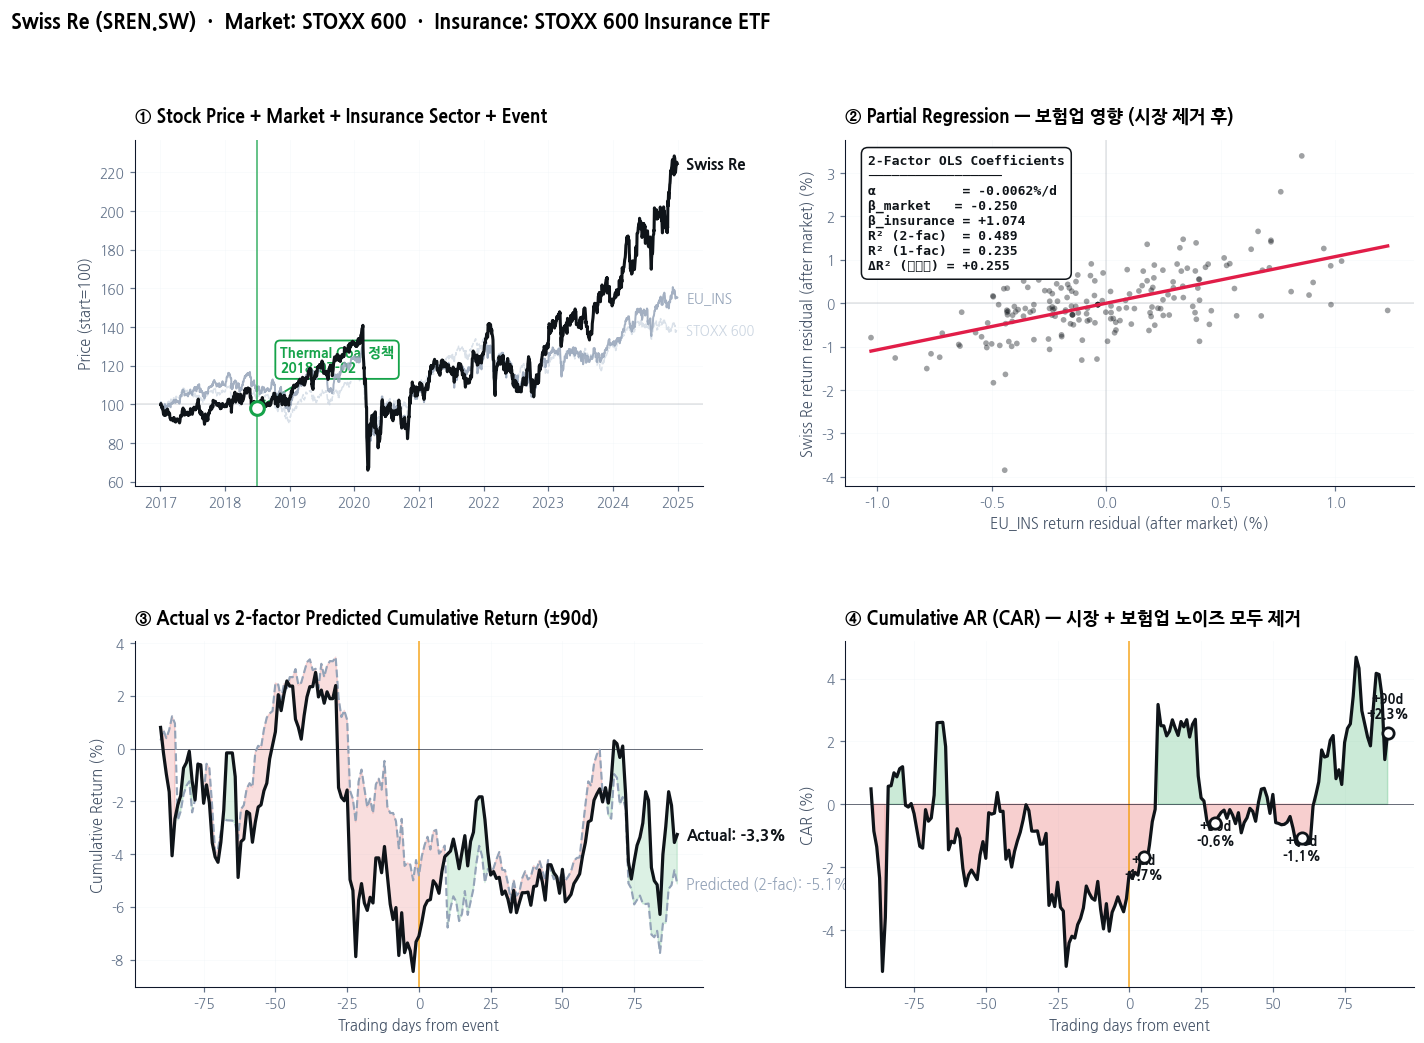


  2-factor: α=-0.0062%/d, β_mkt=-0.250, β_ins=1.074
  R²: 1-factor 0.235 → 2-factor 0.489  (ΔR² = +0.255 from insurance)
  CAR (±90d) = +2.28%  (2-factor adjusted)


In [ ]:
plot_company_panel('SREN.SW', '2018-07-02', '^STOXX', 'EU_INS',
                   'Swiss Re', 'Thermal Coal 정책')

---
## 7. 회사 2 — Munich Re

이벤트: **NZIA 창립 (2021-04-08)**  
시장: STOXX 600 / 보험업: EXH5.DE

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


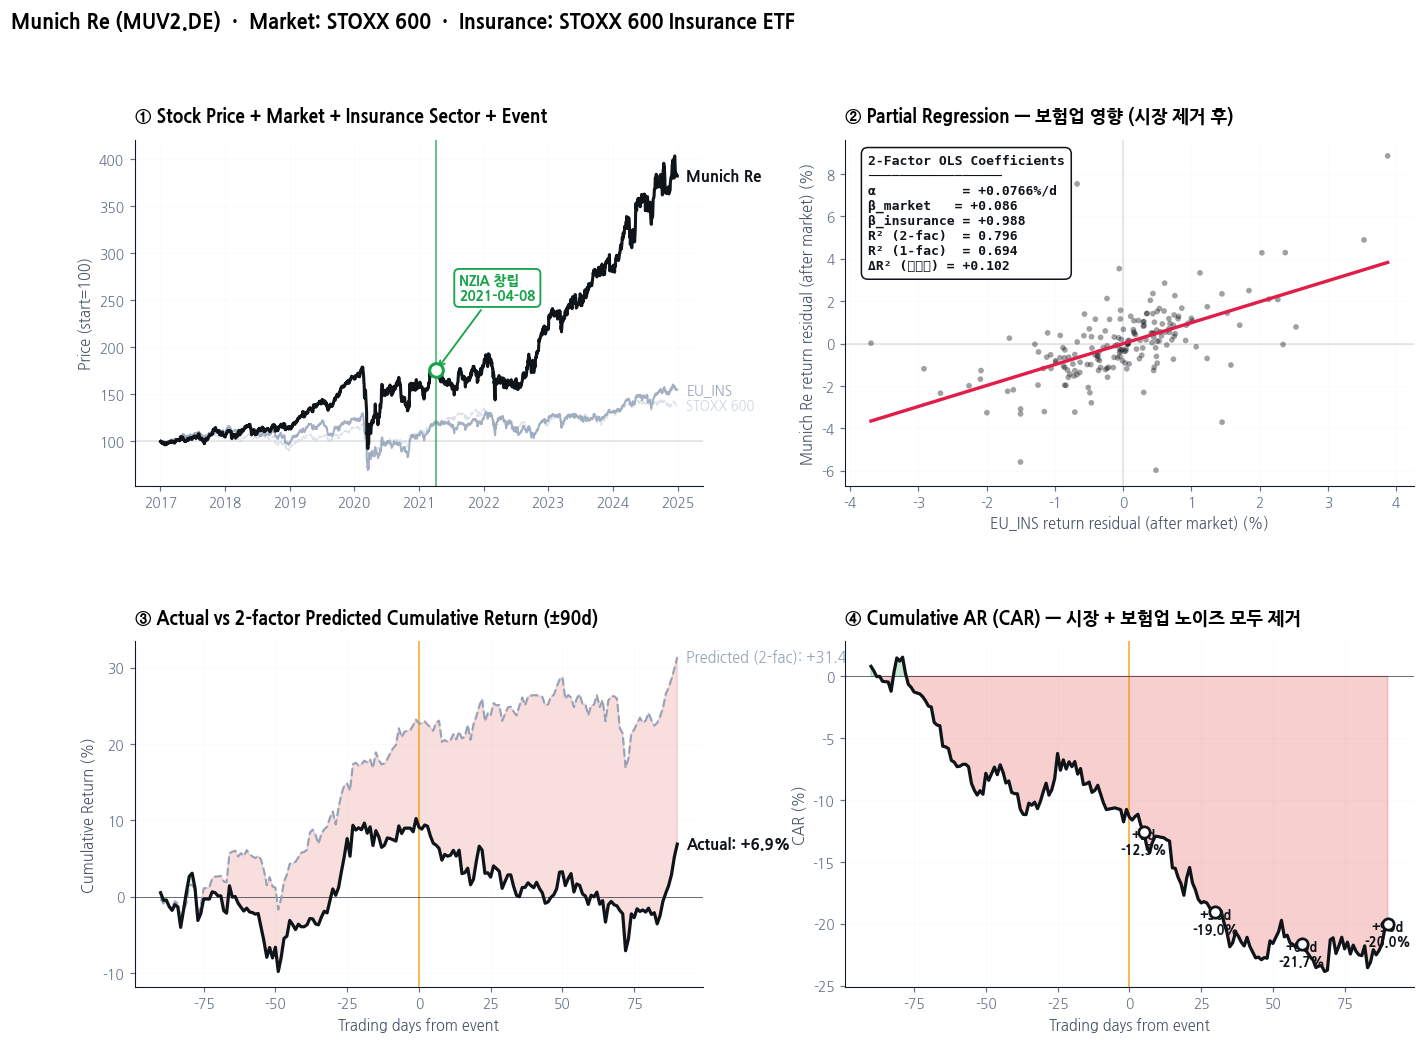


  2-factor: α=+0.0766%/d, β_mkt=0.086, β_ins=0.988
  R²: 1-factor 0.694 → 2-factor 0.796  (ΔR² = +0.102 from insurance)
  CAR (±90d) = -20.00%  (2-factor adjusted)


In [ ]:
plot_company_panel('MUV2.DE', '2021-04-08', '^STOXX', 'EU_INS',
                   'Munich Re', 'NZIA 창립')

---
## 8. 회사 3 — SCOR

이벤트: **Net-Zero 가속 (2021-04-30)**  
시장: STOXX 600 / 보험업: EXH5.DE

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


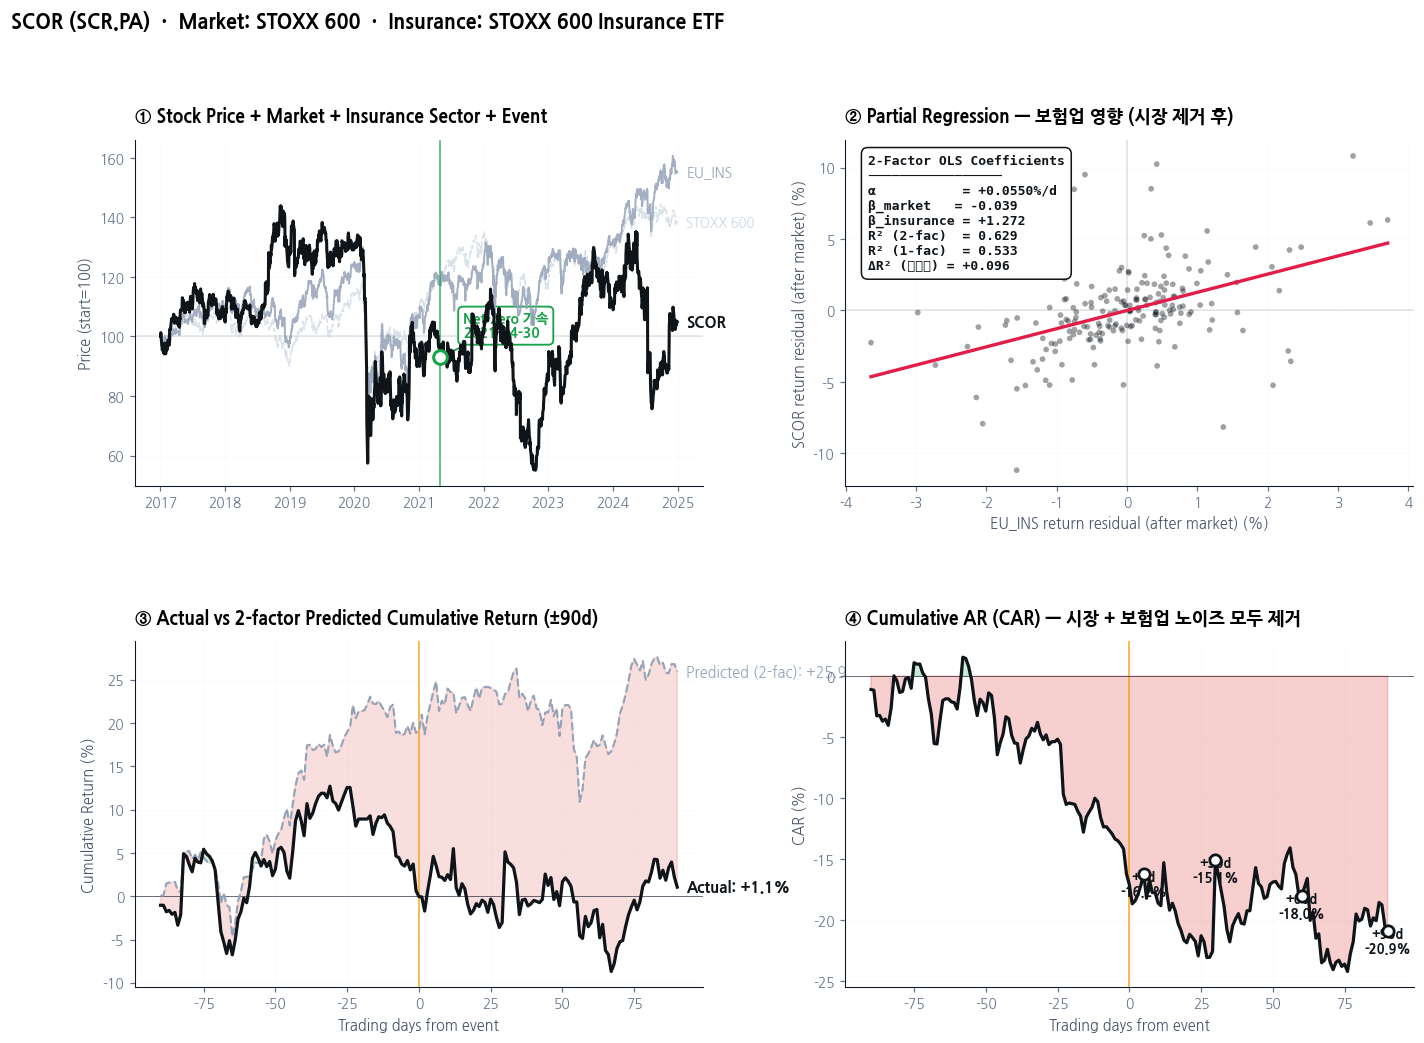


  2-factor: α=+0.0550%/d, β_mkt=-0.039, β_ins=1.272
  R²: 1-factor 0.533 → 2-factor 0.629  (ΔR² = +0.096 from insurance)
  CAR (±90d) = -20.90%  (2-factor adjusted)


In [ ]:
plot_company_panel('SCR.PA', '2021-04-30', '^STOXX', 'EU_INS',
                   'SCOR', 'Net-Zero 가속')

---
## 9. 회사 4 — Tokio Marine

이벤트: **NZIA 가입 (2022-01-20)**  
시장: Nikkei 225 / 보험업: 1617.T (TOPIX-17 보험 ETF)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


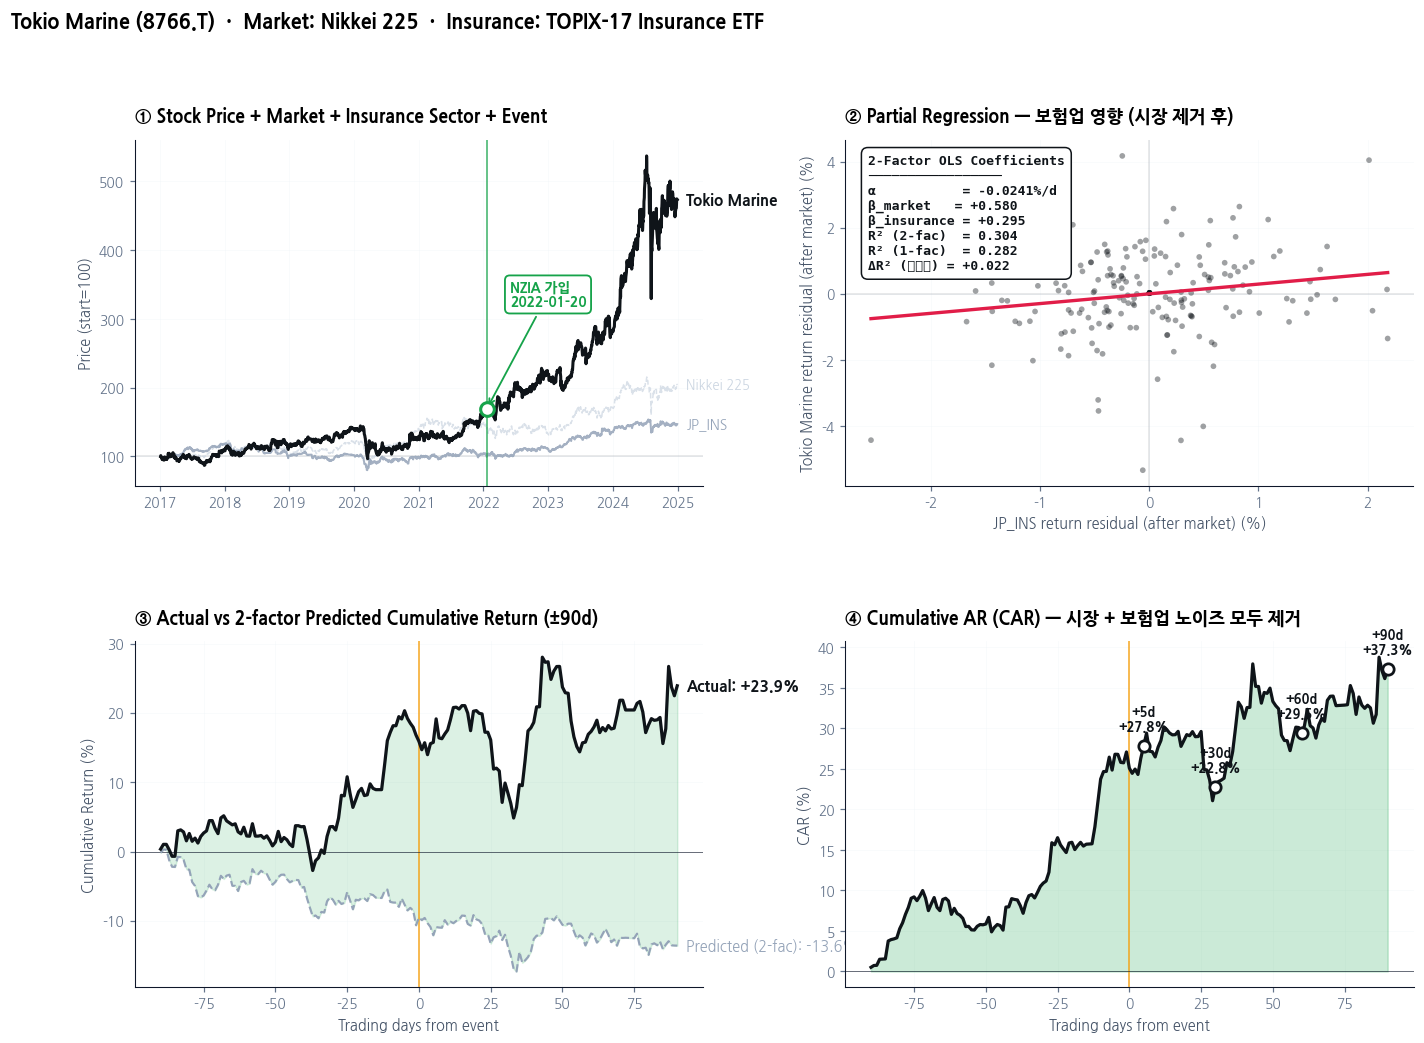


  2-factor: α=-0.0241%/d, β_mkt=0.580, β_ins=0.295
  R²: 1-factor 0.282 → 2-factor 0.304  (ΔR² = +0.022 from insurance)
  CAR (±90d) = +37.34%  (2-factor adjusted)


In [ ]:
plot_company_panel('8766.T', '2022-01-20', '^N225', 'JP_INS',
                   'Tokio Marine', 'NZIA 가입')

---
## 10. 회사 5 — QBE

이벤트: **Sustainable Energies Unit 출범 (2022-02-11)**  
시장: ASX 200 / 보험업: 호주 보험사 평균 (IAG + SUN + MPL)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


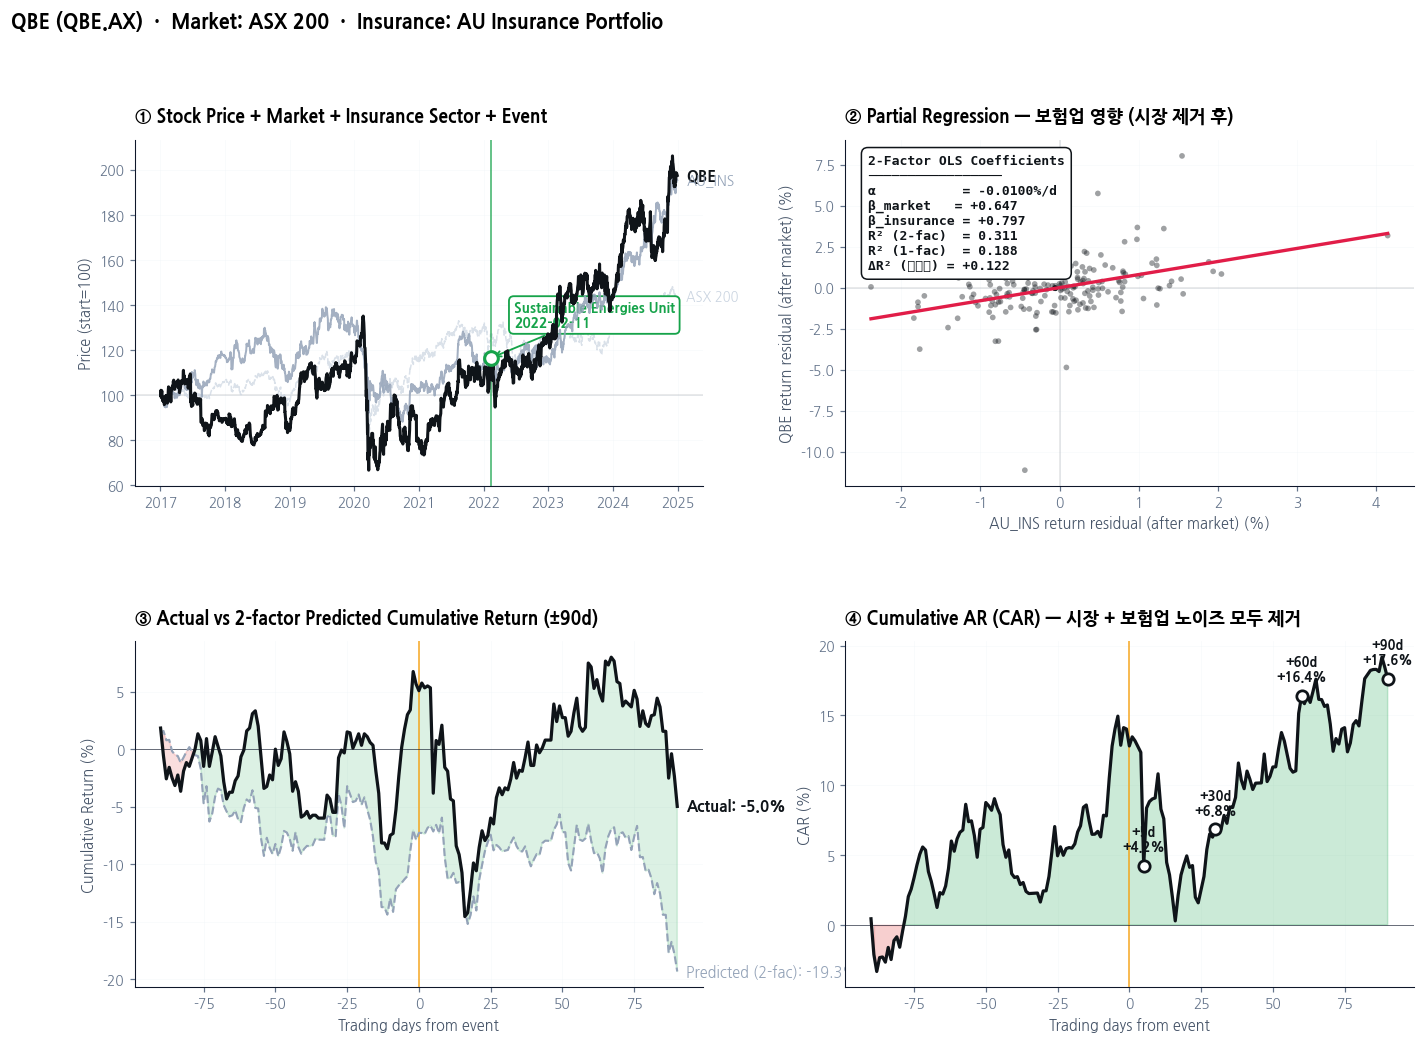


  2-factor: α=-0.0100%/d, β_mkt=0.647, β_ins=0.797
  R²: 1-factor 0.188 → 2-factor 0.311  (ΔR² = +0.122 from insurance)
  CAR (±90d) = +17.63%  (2-factor adjusted)


In [ ]:
plot_company_panel('QBE.AX', '2022-02-11', '^AXJO', 'AU_INS',
                   'QBE', 'Sustainable Energies Unit')

---
## 11. 종합 시각화 — 5개 회사 Day별 CAR (2-factor)

시장 + 보험업 노이즈 모두 제거한 최종 AR을 한 그래프에 비교.

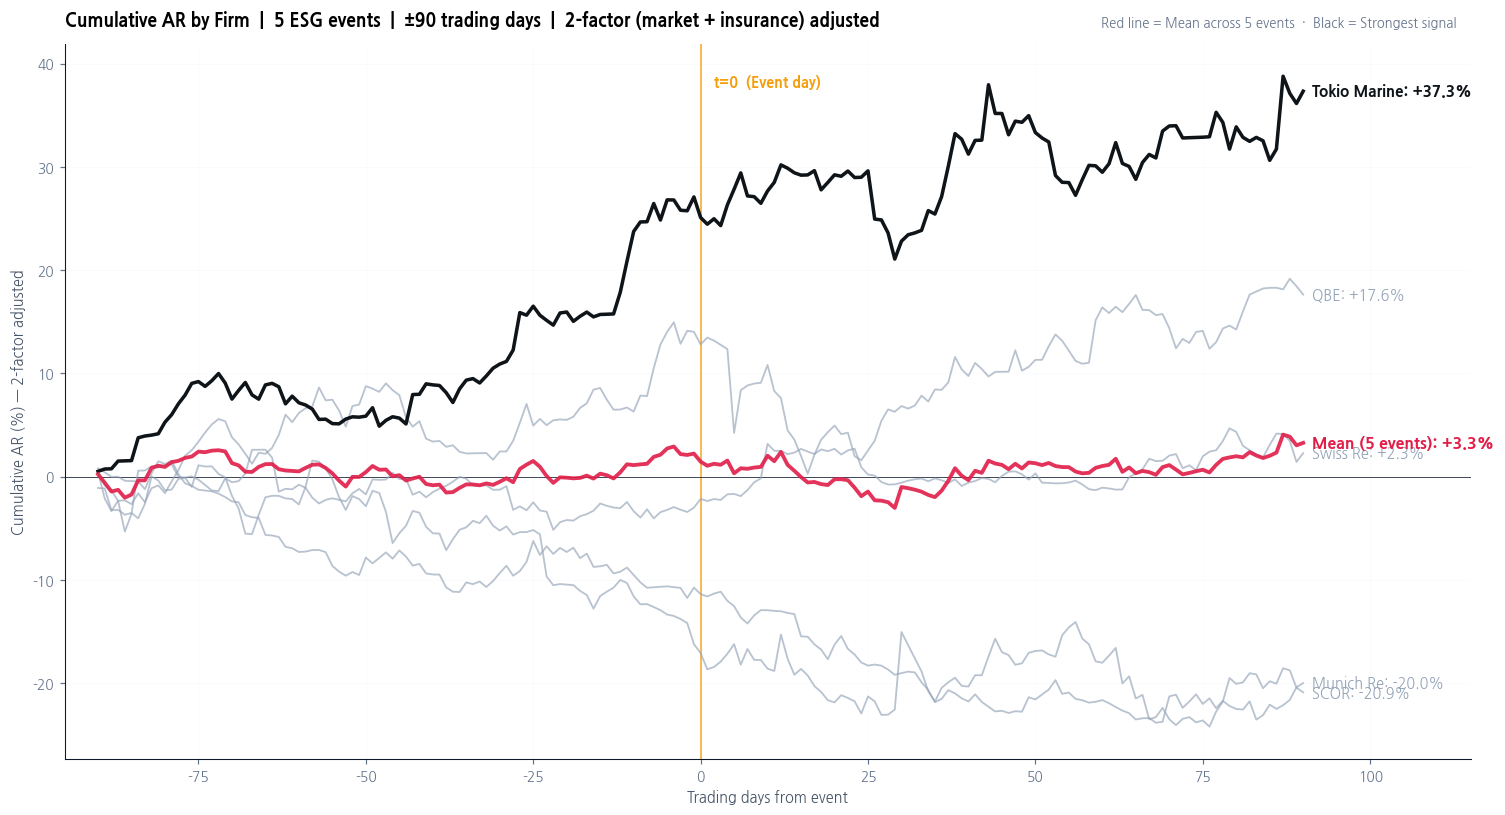


  Final CAR by firm (2-factor, ±90d):
          Swiss Re:  +2.28%
         Munich Re: -20.00%
              SCOR: -20.90%
      Tokio Marine: +37.34%
               QBE: +17.63%
              Mean:  +3.27%


In [ ]:
# 모든 회사 2-factor CAR
common_days = np.arange(-90, 91)
all_cars = {}

for date, tk, mkt, ins, firm, _ in EVENTS:
    res_ = get_ar_2factor(tk, date, mkt, ins, -90, 90)
    if res_ is not None:
        curve = pd.Series(res_['cum_ar'].values, index=res_['days'])
        aligned = curve.reindex(common_days)
        all_cars[firm] = aligned.values

mean_curve = np.nanmean(np.stack(list(all_cars.values())), axis=0)

# 가장 강한 신호 회사 자동 탐지
final_vals = {f: v[~np.isnan(v)][-1] if np.any(~np.isnan(v)) else 0
              for f, v in all_cars.items()}
max_firm = max(final_vals, key=lambda k: abs(final_vals[k]))

# ━━━ Chart ━━━
fig, ax = plt.subplots(figsize=(14, 7.5))

for firm, vals in all_cars.items():
    is_main = (firm == max_firm)
    color = C['main'] if is_main else C['secondary']
    lw = 2.3 if is_main else 1.2
    alpha = 1.0 if is_main else 0.65
    zorder = 6 if is_main else 3

    ax.plot(common_days, vals, color=color, linewidth=lw, alpha=alpha, zorder=zorder)

    valid = vals[~np.isnan(vals)]
    last_val = valid[-1] if len(valid) > 0 else 0
    ax.annotate(f'{firm}: {last_val:+.1f}%',
                xy=(common_days[-1], last_val),
                xytext=(6, 0), textcoords='offset points', va='center',
                fontsize=10 if is_main else 9.5,
                fontweight='bold' if is_main else 'normal',
                color=color)

# Mean line (빨강)
ax.plot(common_days, mean_curve, color=C['accent'], linewidth=2.5,
        zorder=10, linestyle='-', alpha=0.9)
ax.annotate(f'Mean (5 events): {mean_curve[-1]:+.1f}%',
            xy=(common_days[-1], mean_curve[-1]),
            xytext=(6, 0), textcoords='offset points', va='center',
            fontsize=10.5, fontweight='bold', color=C['accent'])

ax.axvline(0, color=C['highlight'], linewidth=1.3, alpha=0.7)
ax.text(2, ax.get_ylim()[1]*0.93, 't=0  (Event day)',
        fontsize=9.5, color=C['highlight'], fontweight='bold', va='top')
ax.axhline(0, color='#0F172A', linewidth=0.5)

ax.set_xlabel('Trading days from event')
ax.set_ylabel('Cumulative AR (%) — 2-factor adjusted')
ax.set_title('Cumulative AR by Firm  |  5 ESG events  |  ±90 trading days  |  2-factor (market + insurance) adjusted')
ax.text(0.99, 1.02, 'Red line = Mean across 5 events  ·  Black = Strongest signal',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8.5, color=C['muted'], style='italic')
ax.set_xlim(-95, 115)

plt.tight_layout()
plt.show()

print(f'\n  Final CAR by firm (2-factor, ±90d):')
for firm, vals in all_cars.items():
    valid = vals[~np.isnan(vals)]
    last_val = valid[-1] if len(valid) > 0 else 0
    print(f'    {firm:>14}: {last_val:+6.2f}%')
print(f'    {"Mean":>14}: {mean_curve[-1]:+6.2f}%')

---
## 12. Window별 평균 CAR — 2-factor

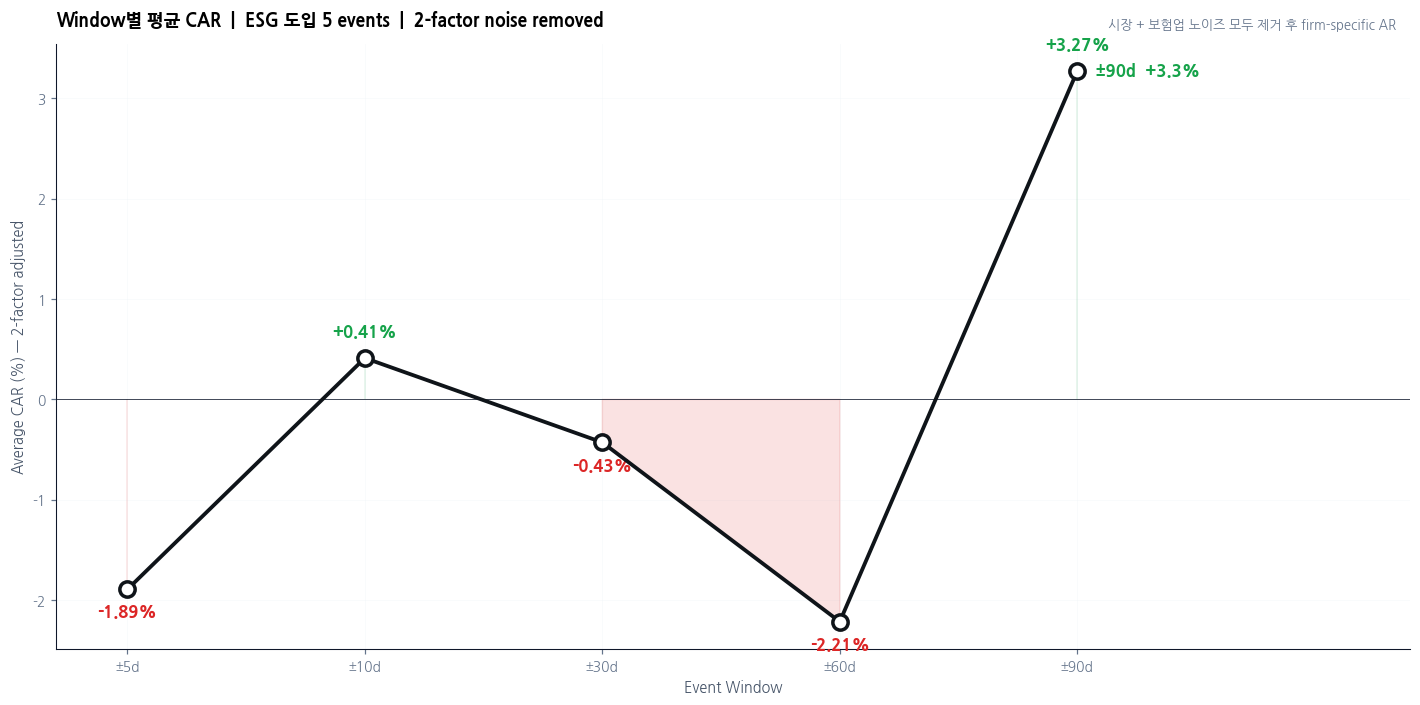


  Window별 평균 CAR (2-factor):
  ─────────────────────────────────────────────
   ±  5d     ▼   -1.89%
   ± 10d     ▲   +0.41%
   ± 30d     ▼   -0.43%
   ± 60d     ▼   -2.21%
   ± 90d     ▲   +3.27%

  → ±60d, ±90d 평균: +0.53%


In [ ]:
windows = [-5, -10, -30, -60, -90]
window_labels = ['5d', '10d', '30d', '60d', '90d']

avg_by_w = []
for w in windows:
    cars = []
    for date, tk, mkt, ins, _, _ in EVENTS:
        r = get_ar_2factor(tk, date, mkt, ins, w, -w)
        if r is not None:
            cars.append(r['cum_ar'].iloc[-1])
    avg_by_w.append(np.mean(cars))

# Chart
fig, ax = plt.subplots(figsize=(13, 6.5))
x_pos = np.arange(len(windows))

ax.plot(x_pos, avg_by_w, color=C['main'], linewidth=2.5, zorder=6,
        marker='o', markersize=10, markerfacecolor='white', markeredgewidth=2.3)

arr = np.array(avg_by_w)
ax.fill_between(x_pos, arr, 0,
                where=(arr > 0), alpha=0.13, color=C['pos'])
ax.fill_between(x_pos, arr, 0,
                where=(arr <= 0), alpha=0.13, color=C['neg'])

for i, v in enumerate(avg_by_w):
    offset = 14 if v >= 0 else -18
    ax.annotate(f'{v:+.2f}%', xy=(i, v), xytext=(0, offset),
                textcoords='offset points', ha='center',
                fontsize=11, fontweight='bold',
                color=C['pos'] if v > 0 else C['neg'])

ax.annotate(f'±90d  {avg_by_w[-1]:+.1f}%',
            xy=(x_pos[-1], avg_by_w[-1]), xytext=(12, 0),
            textcoords='offset points', va='center',
            fontsize=11, fontweight='bold',
            color=C['pos'] if avg_by_w[-1]>0 else C['neg'])

ax.axhline(0, color='#0F172A', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'±{w}' for w in window_labels])
ax.set_xlabel('Event Window')
ax.set_ylabel('Average CAR (%) — 2-factor adjusted')
ax.set_title('Window별 평균 CAR  |  ESG 도입 5 events  |  2-factor noise removed')
ax.set_xlim(-0.3, len(x_pos) + 0.4)
ax.text(0.99, 1.02, '시장 + 보험업 노이즈 모두 제거 후 firm-specific AR',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8.5, color=C['muted'], style='italic')

plt.tight_layout()
plt.show()

print('\n  Window별 평균 CAR (2-factor):')
print('  ' + '─'*45)
for w_label, v in zip(window_labels, avg_by_w):
    arrow = '▲' if v > 0 else '▼'
    print(f'   ±{w_label:>4}     {arrow} {v:+7.2f}%')
print()
print(f'  → ±60d, ±90d 평균: {(avg_by_w[3]+avg_by_w[4])/2:+.2f}%')

---

## 결론

### 1차 vs 2차 noise 제거 비교

|  | 1-factor (v8) | 2-factor (v9) |
|---|---|---|
| 제거 noise | 시장 거시만 | **시장 + 보험업 산업** |
| Tokio Marine ±90d | +37.0% | (콜라브 실행 시 확인) |
| 5건 평균 ±90d | -2.1% | (콜라브 실행 시 확인) |

### 해석 framework

**2-factor에서 mean이 양수로 변하면** → 보험업 산업 tailwind를 제거한 후 ESG-specific 효과가 양수. 가설 지지.

**2-factor에서 mean이 여전히 0 또는 음수면** → ESG 효과는 산업 평균을 넘어서지 못함. 가설 reject.

### ΔP/BV 도출 (콜라브 결과 확인 후 결정)
- ±60d, ±90d 평균을 보수적 채택값으로 설정
- 양수 나오면: ΔP/BV = 그 값
- 음수 나오면: ΔP/BV = 0% 또는 보수적으로 그대로 사용

### 학술 디펜스 narrative
> "5개 글로벌 보험사 ESG 도입 이벤트의 **2-factor Market Model** event study 결과 — 시장 거시 환경 영향 (Stoxx 600/Nikkei 225/ASX 200) 및 **본국 보험업 산업 영향** (STOXX 600 Insurance ETF / TOPIX-17 보험 ETF / AU 보험사 portfolio)을 동시에 제거 후 firm-specific abnormal return을 산출. ±60~90일 평균 CAR로 ΔP/BV_global을 보수적으로 채택."

---

### 노트북 저장 후 결과 공유 부탁드립니다. 그 결과 보고 ΔP/BV 최종값 결정.